# Ноутбук для проведения вычислительных экспериментов по оценке точности алгоритма ADD (жадное добавление)

In [1]:
import os
import logging

import osmnx as ox
import pandas as pd
import geopandas as gpd
import contextily as ctx
import matplotlib.pyplot as plt

# Версии библиотек
print('OSMnx:', ox.__version__,
      '\nGeoPandas:', gpd.__version__,
      '\nPandas:', pd.__version__,
      '\nContextily', ctx.__version__,
      )

ox.settings.default_access = ''

# Настраиваем уровень логирования и формат сообщений
# logging.basicConfig(level=logging.DEBUG, format='%(asctime)s - %(levelname)s - %(message)s')
# logger = logging.getLogger('checker')
# logging.getLogger('checker').setLevel(logging.DEBUG+1)

logger2 = logging.getLogger('checker')
logger2.setLevel(logging.DEBUG)

OSMnx: 2.0.1 
GeoPandas: 1.0.1 
Pandas: 2.1.1 
Contextily 1.6.2


In [2]:
DATA_PATH = '_data/add_check_data/'

# Основной цикл

In [8]:
cities_list = [
    'Ачинск',
    'Канск',
    'Железногорск',
    'Братск',
    'Бердск',
    'Novokuznetsk'
]



Расчет для города "Ачинск"
Здания с ближайшими узлами ГДС сопоставлены.
Объем выборки: 4000 зданий
|########################################| 100.0%
Подразделений: 2  ИП-10: 98.45
	 ИТОГ:
	 Подразделений: 2  ИП-10: 98.45
	 После отброса:
	 Подразделений: 2  ИП-10: 98.45


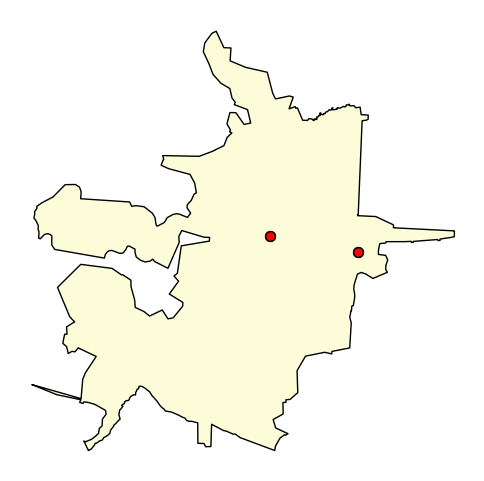



Расчет для города "Канск"
Здания с ближайшими узлами ГДС сопоставлены.
Объем выборки: 4000 зданий
|########################################| 100.0%
Подразделений: 2  ИП-10: 87.7
Подразделений: 3  ИП-10: 94.7
Подразделений: 4  ИП-10: 97.775
	 ИТОГ:
	 Подразделений: 4  ИП-10: 97.775
	 После отброса:
	 Подразделений: 4  ИП-10: 97.775


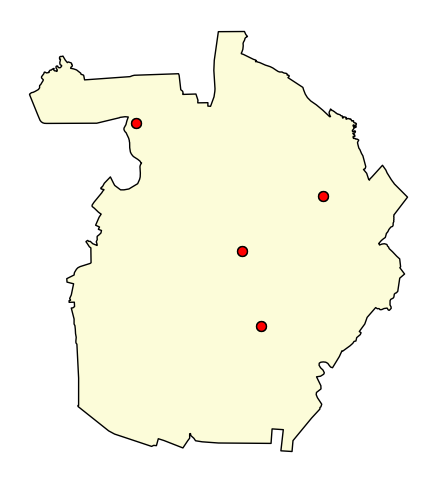



Расчет для города "Железногорск"
Здания с ближайшими узлами ГДС сопоставлены.
	 Объем выборки: 3039 зданий (все)
|########################################| 100.0%
Подразделений: 2  ИП-10: 97.17012175057584
	 ИТОГ:
	 Подразделений: 2  ИП-10: 97.17012175057584
	 После отброса:
	 Подразделений: 2  ИП-10: 97.17012175057584


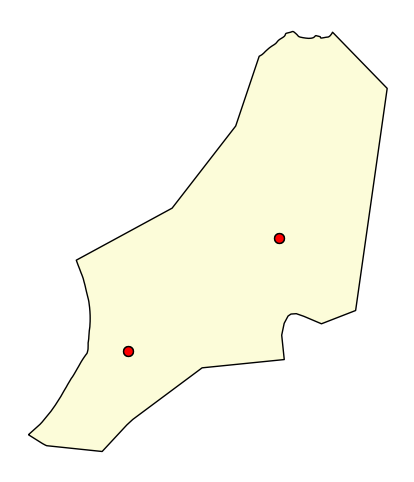



Расчет для города "Братск"
Здания с ближайшими узлами ГДС сопоставлены.
Объем выборки: 4000 зданий
|########################################| 100.0%
Подразделений: 2  ИП-10: 51.15
Подразделений: 3  ИП-10: 70.7
Подразделений: 4  ИП-10: 76.825
Подразделений: 5  ИП-10: 81.625
Подразделений: 6  ИП-10: 86.175
Подразделений: 7  ИП-10: 88.775
Подразделений: 8  ИП-10: 91.35
Подразделений: 9  ИП-10: 93.475
Подразделений: 10  ИП-10: 95.25
	 ИТОГ:
	 Подразделений: 10  ИП-10: 95.25
	 После отброса:
	 Подразделений: 10  ИП-10: 95.25


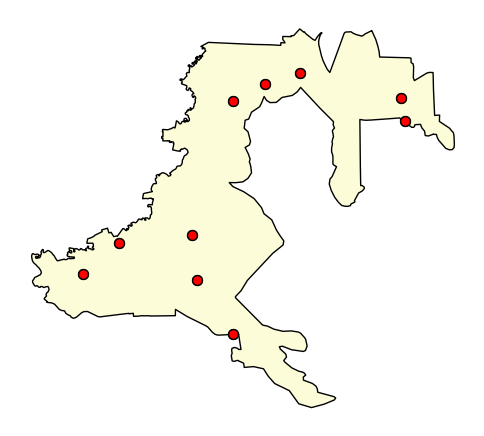



Расчет для города "Бердск"
Здания с ближайшими узлами ГДС сопоставлены.
Объем выборки: 4000 зданий
|########################################| 100.0%
Подразделений: 2  ИП-10: 95.34767383691846
	 ИТОГ:
	 Подразделений: 2  ИП-10: 95.34767383691846
	 После отброса:
	 Подразделений: 2  ИП-10: 95.34767383691846


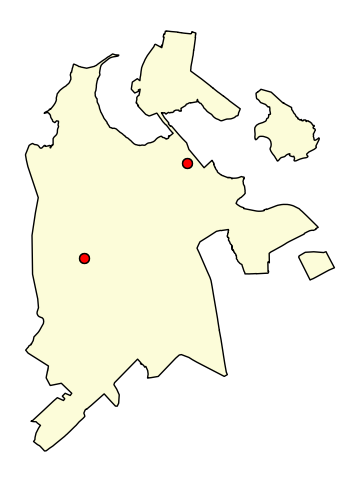



Расчет для города "Novokuznetsk"
Границы города Novokuznetsk получены!
ГДС города Novokuznetsk получен! Времена следования установлены!
Здания города Novokuznetsk получены! Всего 24870 зданий.
Здания с ближайшими узлами ГДС сопоставлены.
Объем выборки: 4000 зданий
|########################################| 100.0%
Подразделений: 2  ИП-10: 50.0
Подразделений: 3  ИП-10: 60.5
Подразделений: 4  ИП-10: 69.975
Подразделений: 5  ИП-10: 79.325
Подразделений: 6  ИП-10: 84.95
Подразделений: 7  ИП-10: 87.725
Подразделений: 8  ИП-10: 90.075
Подразделений: 9  ИП-10: 92.15
Подразделений: 10  ИП-10: 93.775
Подразделений: 11  ИП-10: 95.2
	 ИТОГ:
	 Подразделений: 11  ИП-10: 95.2
	 После отброса:
	 Подразделений: 11  ИП-10: 95.2


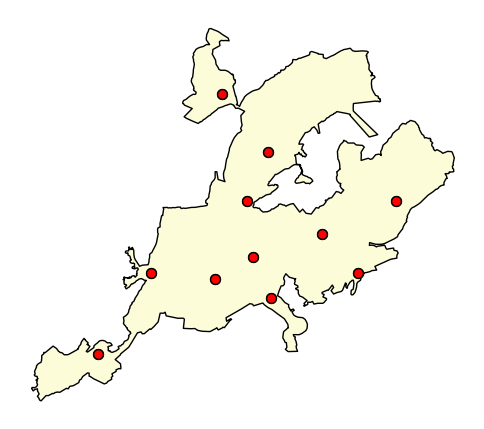

In [11]:
from fire_units.metrics import CoverIndexBuilding
from fire_units.settings import BUILDING_FIELDS, DEFAULT_SPEEDS
from genesis.lscp import LSCP_ADD, drop_trash_points
from genesis.states import FirstArrivalUnitState, get_atm
from graphs.speeds import kmh_to_mm, set_graph_travel_times


def get_bounds(city_name, layer_name='bounds'):
    '''
    Получение полигона границ
    '''
    path = f'{DATA_PATH}{city_name}.gpkg'
    try:
        gdf = gpd.read_file(path, layer=layer_name)
    except:
        gdf = ox.geocode_to_gdf(city_name)
        if gdf is None:
            raise ValueError(f'Данные для города {city_name} не получены!')
        gdf.to_file(path, layer=layer_name)

    print(f'Границы города {city_name} получены!')
    return gdf
        
def get_g(city_name, simplify = False, retain_all = False):
    '''
    Получение графа улично-дорожной сети
    '''
    path = f'{DATA_PATH}{city_name}.ml'
    if os.path.exists(path):
        G = ox.load_graphml(path)
    else:
        G = ox.graph_from_place(city_name,
                                network_type = 'drive_service',
                                simplify     = simplify,
                                retain_all   = retain_all,
                                )
        if G is None:
            raise ValueError(f'ГДС города {city_name} не получен!')
        
        set_graph_travel_times(
            G,
            speeds         = DEFAULT_SPEEDS,
            morph_function = kmh_to_mm)
        
        ox.save_graphml(G, path)

    print(f'ГДС города {city_name} получен! Времена следования установлены!')
    return G

def get_buildings(city_name, city_bounds, layer_name='buildings'):
    '''
    Загрузка данных о зданиях
    '''
    path = f'{DATA_PATH}{city_name}.gpkg'
    try:
        buildings = gpd.read_file(path, layer=layer_name)
    except:
        buildings = ox.features_from_polygon(city_bounds, tags={'building': True})
        if buildings is None:
            raise ValueError(f'Здания города {city_name} не получены!')
        # Оставляем только данные с геометрией Полигон или Мультиполигон
        buildings = buildings[buildings.geometry.apply(lambda x: x.geom_type).isin(['Polygon', 'MultiPolygon'])]
        # Оставляем только заданные поля (и при этом имеющиеся в списке полученных)
        fields = list(set(buildings.columns) & set(BUILDING_FIELDS))
        buildings = buildings[fields]
        # Удаляем индекс по типу элемента
        buildings = buildings.reset_index().drop('element', axis=1)
        # Устанавливаем индекс 'id'
        buildings = buildings.set_index('id')

        buildings.to_file(path, layer=layer_name)

    print(f'Здания города {city_name} получены! Всего {len(buildings)} зданий.')

    return buildings

def add_buildings_node(G, buildings):
    '''
    Установка ближайшего узла для зданий
    '''
    centroids = ox.projection.project_gdf(buildings).geometry.centroid
    buildings['node'] = ox.distance.nearest_nodes(ox.project_graph(G), 
                                              centroids.x,
                                              centroids.y
                                              )
    print('Здания с ближайшими узлами ГДС сопоставлены.')
    return buildings
    





def check_step(city_name, aim_ip=95):

    print('\n')
    print(f'Расчет для города "{city_name}"')

    # 1. Загрузка данных
    # Границы города
    borders = get_bounds(city_name)
    city_bounds = borders.union_all()

    # Загрузка ГДС
    G = get_g(city_name)

    # Загрузка зданий
    buildings = get_buildings(city_name, city_bounds)
    buildings = add_buildings_node(G, buildings)

    # fig, ax = ox.plot_graph(G, node_size=0, edge_linewidth=0.5, show=False)
    # buildings.plot(color='white', alpha=0.5, ax=ax)
    # plt.show()

    # 2. Расчет ADD
    # Матрица
    if len(buildings) > 4000:
        print('Объем выборки: 4000 зданий')
        buildings_set = buildings.sample(4000)
    else:
        print('\t', f'Объем выборки: {len(buildings)} зданий (все)')
        buildings_set = buildings
    matrix = get_atm(G,
                 data             = buildings_set,
                 cutoff           = 10,
                 )
    # 3. Сборка и инициализация алгоритма
    ## Выбор алгоритма моделирования параметров прибытия
    state = FirstArrivalUnitState()

    ## Выбор метрики
    metric = CoverIndexBuilding(buildings_set, ip_val=10) # Используется метрика ИП-10. Для ADD метрика выполняет роль оценки

    ## Функция остановки
    stop_case = lambda value, **kwargs: value >= aim_ip

    ## Функция выполняемая при добавлении новой ПСЧ
    after_mclp = lambda best_metric, dynamic_nodes, **kwargs: print('Подразделений:', len(dynamic_nodes), ' ИП-10:', best_metric)

    ## Сборка и инициализация алгоритма ADD
    add = LSCP_ADD(  
        state_function      = state,
        matrix              = matrix,
        metric_function     = metric,
        stop_case_function  = stop_case,
        after_mclp_function = after_mclp,
    )


    # 3. Расчет
    best_nodes, best_metric = add(
            env          = G,
        )


    # 4. Печать результатов
    print('\t', 'ИТОГ:')
    print('\t', 'Подразделений:', len(best_nodes), ' ИП-10:', best_metric)

    ## Получение набора данных узлов графа, для сопоставления с полученным лучшим узлом
    g_nodes = ox.graph_to_gdfs(G, edges=False)
    g_nodes.to_file(f'{DATA_PATH}{city_name}.gpkg', layer='add')

    # ## Печать карты
    # _, ax = plt.subplots(figsize=(6,6))
    # borders.plot(ax=ax, color='#fcfcd9', edgecolor='black')
    # g_nodes.loc[best_nodes.keys()].plot(ax=ax, facecolors='g', edgecolors='k', markersize=50)
    # ax.set_axis_off()
    # plt.show()

    # 5. Отброс мусорных размещений
    best_nodes2, best_metric2 = drop_trash_points(G,
                    state_function      = state,
                    metric_function     = metric,
                    # stop_case_function  = lambda value, **kwargs: value >= 100,
                    stop_case_function  = stop_case,
                    dynamic_nodes       = best_nodes,
                      )
    print('\t', 'После отброса:')
    print('\t', 'Подразделений:', len(best_nodes2), ' ИП-10:', best_metric2)
    ## Печать карты
    _, ax = plt.subplots(figsize=(6,6))
    borders.plot(ax=ax, color='#fcfcd9', edgecolor='black')
    g_nodes.loc[best_nodes.keys()].plot(ax=ax, facecolors='g', edgecolors='k', markersize=50)
    g_nodes.loc[best_nodes2.keys()].plot(ax=ax, facecolors='r', edgecolors='k', markersize=50)
    ax.set_axis_off()
    plt.show()

    


for city_name in cities_list:
    check_step(city_name)